## Imports & Configuration

All libraries used are from the standard data science stack. No deep learning, no external APIs.

In [1]:
# Standard Library
import os
import re
import warnings
warnings.filterwarnings('ignore')

# Data Manipulation
import numpy as np
import pandas as pd

# Machine Learning
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import PCA
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import normalize

# Visualization
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
matplotlib.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.family': 'DejaVu Sans',
})

# Persistence
import joblib

# Reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("All imports successful.")
print(f"   pandas  : {pd.__version__}")
print(f"   numpy   : {np.__version__}")
print(f"   sklearn : {__import__('sklearn').__version__}")

All imports successful.
   pandas  : 3.0.1
   numpy   : 2.4.3
   sklearn : 1.8.0


---

## 1. Data Loading

The SMS Spam Collection dataset contains 5,574 messages labeled as `ham` (legitimate) or `spam`. The file is tab-separated with no header row. We load it with explicit column names.

In [2]:
# Load Dataset
DATA_PATH = "SMSSpamCollection.txt"

df = pd.read_csv(
    DATA_PATH,
    sep='\t',
    header=None,
    names=['label', 'message'],
    encoding='utf-8'
)

print(f"Dataset shape : {df.shape}")
print(f"Columns       : {list(df.columns)}")
print(f"Missing values: {df.isnull().sum().to_dict()}")
print()
display(df.head(10))

Dataset shape : (5572, 2)
Columns       : ['label', 'message']
Missing values: {'label': 0, 'message': 0}



,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."
5,spam,FreeMsg Hey there darling it's been 3 week's n...
6,ham,Even my brother is not like to speak with me. ...
7,ham,As per your request 'Melle Melle (Oru Minnamin...
8,spam,WINNER!! As a valued network customer you have...
9,spam,Had your mobile 11 months or more? U R entitle...


In [9]:
# Basic Dataset Statistics
print("CLASS DISTRIBUTION")
print(df['label'].value_counts())
print()
print(f"Total messages : {len(df):,}")
print(f"Spam messages  : {(df['label'] == 'spam').sum():,} ({(df['label'] == 'spam').mean()*100:.1f}%)")
print(f"Ham messages   : {(df['label'] == 'ham').sum():,}  ({(df['label'] == 'ham').mean()*100:.1f}%)")

CLASS DISTRIBUTION
label
ham     4825
spam     747
Name: count, dtype: int64

Total messages : 5,572
Spam messages  : 747 (13.4%)
Ham messages   : 4,825  (86.6%)


---

##  2. Exploratory Data Analysis (EDA)

Before building the pipeline, we explore the data to understand class balance, message length distributions, and lexical characteristics. This helps calibrate our feature engineering and anomaly threshold.

In [4]:
# Compute Message
df['msg_length']    = df['message'].str.len()
df['word_count']    = df['message'].str.split().str.len()
df['digit_ratio']   = df['message'].apply(lambda x: sum(c.isdigit() for c in x) / max(len(x), 1))
df['upper_ratio']   = df['message'].apply(lambda x: sum(c.isupper() for c in x) / max(len(x), 1))
df['special_ratio'] = df['message'].apply(lambda x: sum(not c.isalnum() and not c.isspace() for c in x) / max(len(x), 1))
df['has_url']       = df['message'].str.contains(r'http|www|\.(com|net|org)', case=False, regex=True).astype(int)

print("Feature statistics by label:")
display(df.groupby('label')[['msg_length', 'word_count', 'digit_ratio', 'upper_ratio', 'special_ratio', 'has_url']].mean().round(3))

Feature statistics by label:


,msg_length,word_count,digit_ratio,upper_ratio,special_ratio,has_url
label,,,,,,
ham,71.482,14.310,0.004,0.058,0.062,0.004
spam,138.671,23.912,0.117,0.111,0.044,0.166


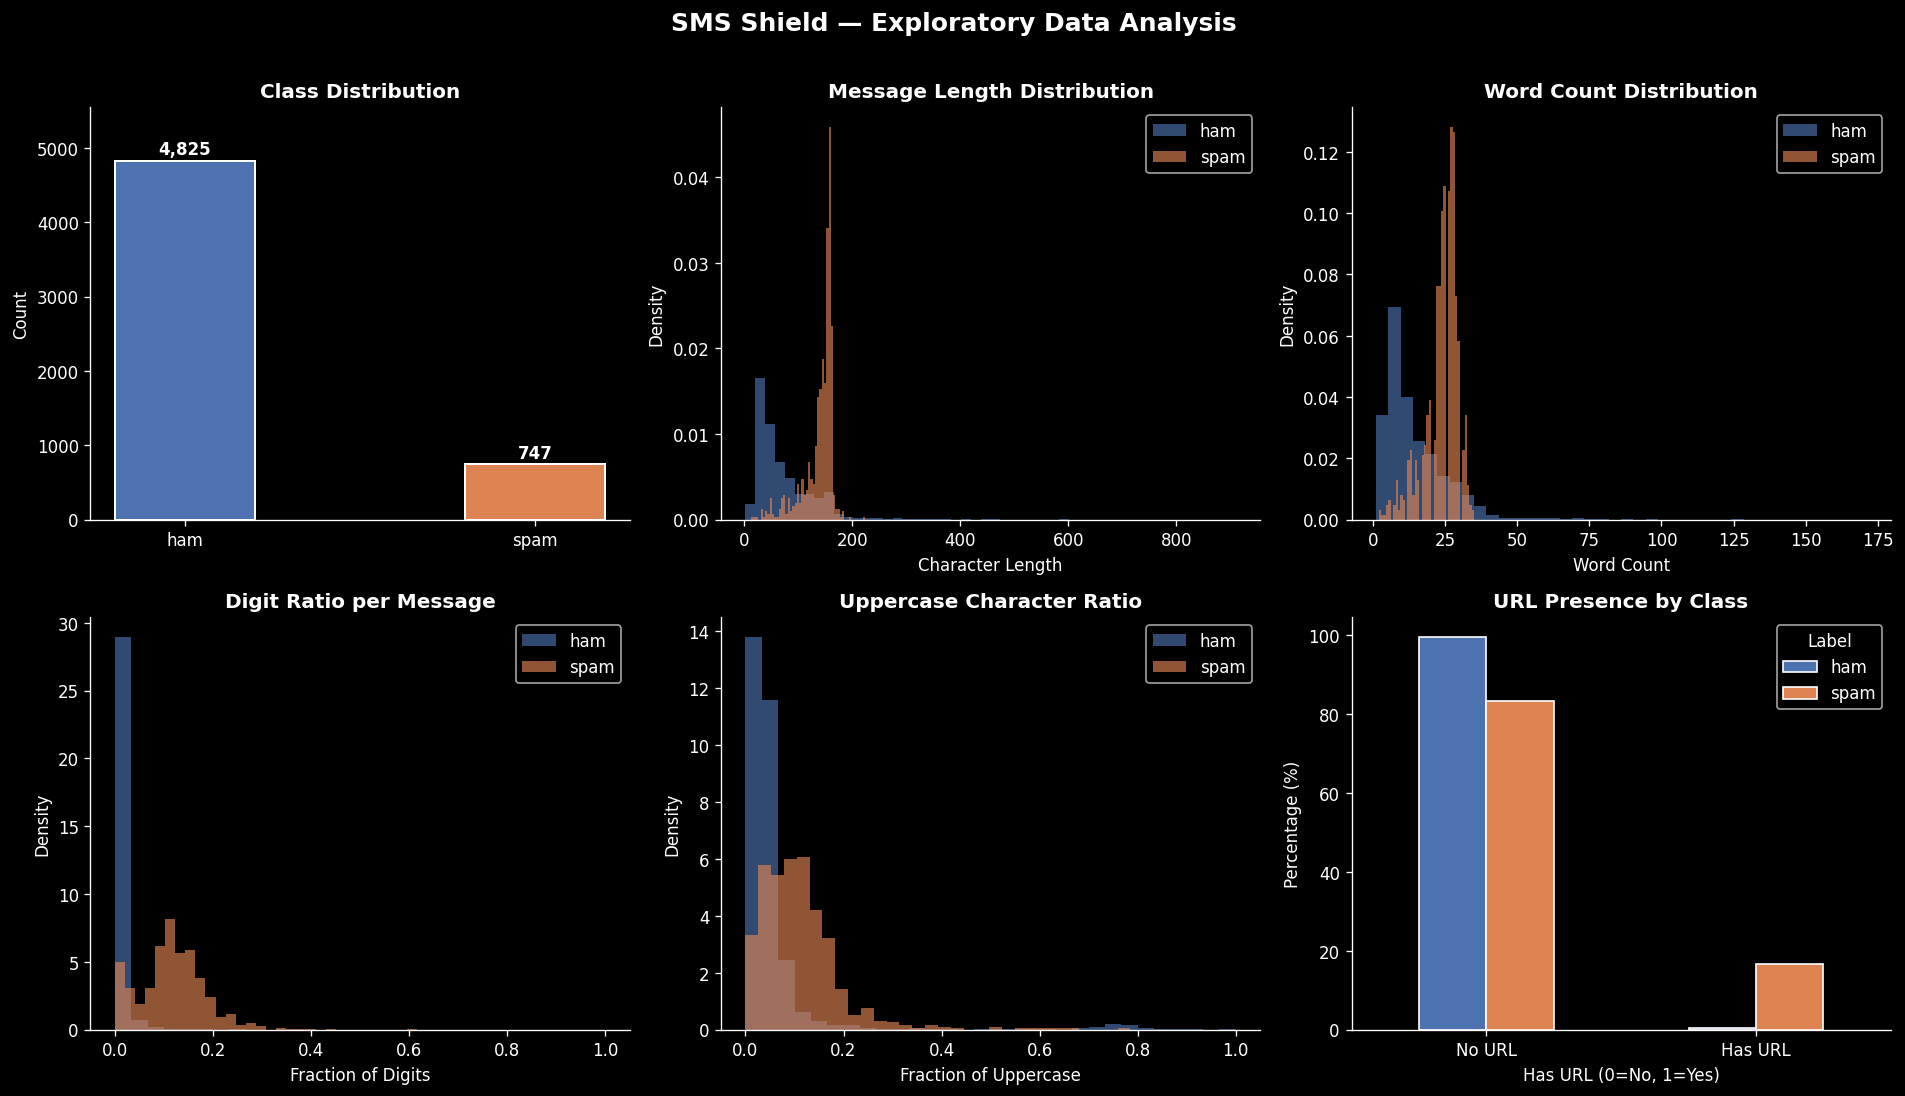

📊 EDA chart saved as 'eda_analysis.png'


In [5]:
# EDA Visualizations
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle('SMS Shield — Exploratory Data Analysis', fontsize=15, fontweight='bold', y=1.01)

COLORS = {'ham': '#4C72B0', 'spam': '#DD8452'}


ax = axes[0, 0]
counts = df['label'].value_counts()
bars = ax.bar(counts.index, counts.values, color=[COLORS[l] for l in counts.index], width=0.4, edgecolor='white', linewidth=1.2)
for bar, val in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30, f'{val:,}', ha='center', va='bottom', fontsize=10, fontweight='bold')
ax.set_title('Class Distribution', fontweight='bold')
ax.set_ylabel('Count')
ax.set_ylim(0, counts.max() * 1.15)

# 2. Message Length
ax = axes[0, 1]
for label, grp in df.groupby('label'):
    ax.hist(grp['msg_length'], bins=50, alpha=0.65, color=COLORS[label], label=label, density=True)
ax.set_title('Message Length Distribution', fontweight='bold')
ax.set_xlabel('Character Length')
ax.set_ylabel('Density')
ax.legend()

# 3. Word Count
ax = axes[0, 2]
for label, grp in df.groupby('label'):
    ax.hist(grp['word_count'], bins=40, alpha=0.65, color=COLORS[label], label=label, density=True)
ax.set_title('Word Count Distribution', fontweight='bold')
ax.set_xlabel('Word Count')
ax.set_ylabel('Density')
ax.legend()

# 4. Digit Ratio
ax = axes[1, 0]
for label, grp in df.groupby('label'):
    ax.hist(grp['digit_ratio'], bins=30, alpha=0.65, color=COLORS[label], label=label, density=True)
ax.set_title('Digit Ratio per Message', fontweight='bold')
ax.set_xlabel('Fraction of Digits')
ax.set_ylabel('Density')
ax.legend()

# 5. Uppercase Ratio
ax = axes[1, 1]
for label, grp in df.groupby('label'):
    ax.hist(grp['upper_ratio'], bins=30, alpha=0.65, color=COLORS[label], label=label, density=True)
ax.set_title('Uppercase Character Ratio', fontweight='bold')
ax.set_xlabel('Fraction of Uppercase')
ax.set_ylabel('Density')
ax.legend()

#6. URL Presence
ax = axes[1, 2]
url_data = df.groupby(['label', 'has_url']).size().unstack(fill_value=0)
url_pct = url_data.div(url_data.sum(axis=1), axis=0) * 100
url_pct.T.plot(kind='bar', ax=ax, color=[COLORS[l] for l in url_pct.index], edgecolor='white')
ax.set_title('URL Presence by Class', fontweight='bold')
ax.set_xlabel('Has URL (0=No, 1=Yes)')
ax.set_ylabel('Percentage (%)')
ax.set_xticklabels(['No URL', 'Has URL'], rotation=0)
ax.legend(title='Label')

plt.tight_layout()
plt.savefig('eda_analysis.png', bbox_inches='tight', dpi=120)
plt.show()
print("📊 EDA chart saved as 'eda_analysis.png'")

---

##  3. Text Preprocessing

We apply lightweight, interpretable cleaning:
- **Lowercase** all text for case-insensitive matching
- **URL normalization** — replace URLs with a token `<url>` (preserves structural information)
- **Number normalization** — replace digit sequences with `<num>`
- **Remove special characters** — strip punctuation noise
- **Whitespace normalization**

We intentionally keep the `<url>` and `<num>` tokens since their *presence* is a strong signal for character n-gram models.

In [6]:
def clean_sms(text: str) -> str:

    text = str(text).lower().strip()
    # Replace URLs with a token
    text = re.sub(r'https?://\S+|www\.\S+', ' url ', text)
    # Replace digit sequences with a token
    text = re.sub(r'\d+', ' num ', text)
    # Remove special characters (keep letters, spaces, token markers)
    text = re.sub(r'[^a-z\s]', ' ', text)
    # Collapse multiple spaces
    text = re.sub(r'\s+', ' ', text).strip()
    return text


# Apply cleaning
df['clean_message'] = df['message'].apply(clean_sms)


print("Before vs. After Cleaning (5 samples):")
print("=" * 80)
for _, row in df[['message', 'clean_message', 'label']].sample(5, random_state=RANDOM_STATE).iterrows():
    print(f"[{row['label'].upper():4s}] ORIGINAL : {row['message'][:80]}")
    print(f"       CLEANED  : {row['clean_message'][:80]}")
    print("-" * 80)

Before vs. After Cleaning (5 samples):
[HAM ] ORIGINAL : Squeeeeeze!! This is christmas hug.. If u lik my frndshp den hug me back.. If u 
       CLEANED  : squeeeeeze this is christmas hug if u lik my frndshp den hug me back if u get nu
--------------------------------------------------------------------------------
[HAM ] ORIGINAL : And also I've sorta blown him off a couple times recently so id rather not text 
       CLEANED  : and also i ve sorta blown him off a couple times recently so id rather not text 
--------------------------------------------------------------------------------
[HAM ] ORIGINAL : Mmm thats better now i got a roast down me! id b better if i had a few drinks d
       CLEANED  : mmm thats better now i got a roast down me i d b better if i had a few drinks do
--------------------------------------------------------------------------------
[HAM ] ORIGINAL : Mm have some kanji dont eat anything heavy ok
       CLEANED  : mm have some kanji dont eat anything heavy

---

## 4. Feature Engineering — Character N-gram Vectorization

Word-level bag-of-words models are easily defeated by:
- Misspellings (`fr33`, `w1n`, `cl1ck`)
- Mixed characters (`F.R.E.E`, `FREEE`)
- New vocabulary in emerging campaigns

**Character n-grams** (substrings of length 3–5) are robust to these tricks because they capture sub-word patterns. `free`, `fr3e`, and `fre3` all share many 3-grams.

### Configuration
- `analyzer='char_wb'` — character n-grams with word boundaries (better than raw `char` for short texts)
- `ngram_range=(3, 5)` — trigrams to 5-grams
- `max_features=5000` — top 5,000 most frequent n-grams
- `min_df=3` — ignore extremely rare n-grams (noise reduction)

In [7]:
# Character N-gram Vectorization
vectorizer = CountVectorizer(
    analyzer='char_wb',
    ngram_range=(3, 5),
    max_features=5000,
    min_df=3,
    strip_accents='unicode'
)

X_sparse = vectorizer.fit_transform(df['clean_message'])

print(f"Vocabulary size (fitted) : {len(vectorizer.vocabulary_):,}")
print(f"Feature matrix shape     : {X_sparse.shape}")
print(f"Matrix sparsity          : {1 - X_sparse.nnz / (X_sparse.shape[0] * X_sparse.shape[1]):.2%}")
print()

# Top 20 most frequent n-grams
feature_names = vectorizer.get_feature_names_out()
freq = np.asarray(X_sparse.sum(axis=0)).ravel()
top_idx = freq.argsort()[::-1][:20]
print("Top 20 most frequent character n-grams:")
print(pd.DataFrame({'ngram': feature_names[top_idx], 'frequency': freq[top_idx].astype(int)}).to_string(index=False))

Vocabulary size (fitted) : 5,000
Feature matrix shape     : (5572, 5000)
Matrix sparsity          : 98.03%

Top 20 most frequent character n-grams:
ngram  frequency
   nu       4675
  num       4664
  num       4661
  um        4620
 num        4552
 num        4551
   th       3896
   to       3119
   yo       3042
   i        3032
  you       2986
  you       2984
  ing       2643
  ng        2606
 ing        2462
  the       2389
  to        2334
  to        2253
  ou        2253
 you        2248
